# Trajectory Visualisation and Animation

We can use the ``dump.melt`` file to look at snapshots of the system at different times, and to visualise the system evolution. 

We can get the coordinates of every molecule at the sampled timesteps from the ``'dump.melt'`` file. We can use Python to convert this data into a useful format.

Here we write a script, to parse the ``'dump.melt'`` file and extract all of the particle positions.

In [ ]:
timestep = []
positions = []

# writing a loop to extract the position of every atom at each recorded timestep
with open("dump.melt") as file:
    # creating variables that tells us if we should extract data from the file or not
    coordinate = False
    step = False
    tempcoords = []
    
    # looping over each line of the file to check what it contains
    for line in file:
        
        #script to execute if 'step' condition is true
        if step == True:
            timestep.append(float(line))
            step = False
        
        # setting 'coordinate' to false and 'step' to true if 
        #'ITEM: TIMESTEP' is in the line
        if 'ITEM: TIMESTEP' in line:
            coordinate = False
            step = True
        
        # script to execute if 'step' is true
        if coordinate == True:
            tempcoords.append([float(line.split()[2]), 
                               float(line.split()[3]), float(line.split()[4])])
            if float(line.split()[0]) == 4000:
                positions.append(tempcoords)
                tempcoords = []

        # setting 'coordinate' to true if 'ITEM: ATOMS' is in the line
        if 'ITEM: ATOMS' in line:
            coordinate = True
            

## Snapshots 

We can now make a 3D plot of this data using the corresponding coordinate values for a given snapshot of time.

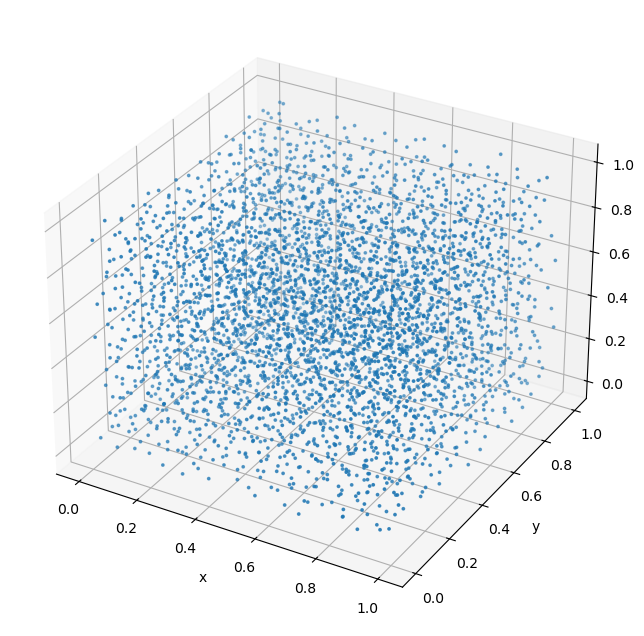

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# picking the snapshot to illustrate
coords = np.array(positions[50]).T.tolist()


# making a 3d figure scatter plot
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(projection='3d')
ax.scatter(coords[0], coords[1], coords[2], s=3)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
plt.show()

## Animation

We can use the trajectories to create animated visualisations for the system.

In [ ]:
# importing some relevant Python libraries for animating
from matplotlib.animation import FuncAnimation
from mpl_toolkits import mplot3d
from IPython.display import HTML
import matplotlib
matplotlib.rcParams['animation.embed_limit'] = 64

# 3d visualisation
xyz=[[],[],[]]
fig, ax = plt.subplots(figsize=(8,8))


def animation_func_3d(i):
    
    # specifiying that 'ax' being used is the global one defined outside of the loop
    global ax
    
    ax.clear()
    plt.axis('off')
    
    xyz = np.array(positions[i]).T.tolist()
    ax = fig.add_subplot(projection='3d')
    ax.scatter(xyz[0], xyz[1], xyz[2], s=4)
    ax.set_xlim(0.1,0.9) 
    ax.set_ylim(0.1,0.9)
    ax.set_zlim(0.1,0.9)
    plt.title(f"Timestep: {int(timestep[i])}")
    ax.set_axis_off()
    plt.tight_layout


animation = FuncAnimation(fig, animation_func_3d, interval = 65, frames=len(timestep))
#animation.save('animation3d.gif', writer='pillow')

HTML(animation.to_jshtml())

Using one axis as a "depth", we can also creat